In [1]:
TARGET_COL = 'H3N2_proxy_d28'  # task 4.2 (proxy for missing Massachusetts strain)

# Task 4.2

**4.2 predict magnitude of antibody response - H3N2 A/Massachusetts/18/2022 (D28)**
* Training Data: Demographics + Day 0 + Day 7 innate
* Assay: HAI
* Measure: Single strain titer
* Metric: Spearman correlation
* Full description: HAI titer for H3N2 A/Massachusetts/18/2022 at Day 28

## Task 4.2: Focus
Magnitude refers to the strength of the antibody response against a single specific vaccine strain.
We are predicting the HAI titer for H3N2 A/Massachusetts/18/2022 at Day 28 post-vaccination.

In [2]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_predict, KFold
from sklearn.pipeline import Pipeline

from data_cleaning.utils import peek

In [3]:
import os
import sys

if '..' not in sys.path:
    sys.path.insert(0, '..')

USE_GOOGLE_COLAB = False

if USE_GOOGLE_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_PATH = os.path.join(os.getcwd(), 'drive', 'MyDrive', 'DSE_260A', 'data', 'cleaned_data')
else:
    DATA_PATH = '../cleaned_data'

In [4]:
train_participants = pd.read_csv(DATA_PATH + '/participants_cleaned.csv')
train_hai = pd.read_csv(DATA_PATH + '/hai_cleaned.csv')

In [5]:
for name, df in {'train_hai': train_hai, 'train_participants': train_participants}.items():
    print(f"\n{'=' * 50}")
    print(f'TABLE: {name}')
    print(f"{'=' * 50}")
    display(peek(df))


TABLE: train_hai


,participant_id,HAI_Anc B/Lee/1940_d0,HAI_Anc B/Lee/1940_d28,HAI_Anc B/Lee/1940_d365,HAI_Anc B/Maryland/1959_d0,HAI_Anc B/Maryland/1959_d28,HAI_Anc B/Singapore/1964_d0,HAI_Anc B/Singapore/1964_d28,HAI_H1N1 A/Beijing/262/1995_d0,HAI_H1N1 A/Beijing/262/1995_d28,HAI_H1N1 A/Beijing/262/1995_d365,HAI_H1N1 A/Brazil/11/1978_d0,HAI_H1N1 A/Brazil/11/1978_d28,HAI_H1N1 A/Brazil/11/1978_d365,HAI_H1N1 A/Brisbane/2/2018_d0,HAI_H1N1 A/Brisbane/2/2018_d28,HAI_H1N1 A/Brisbane/2/2018_d365,HAI_H1N1 A/Brisbane/59/2007_d0,HAI_H1N1 A/Brisbane/59/2007_d28,HAI_H1N1 A/Brisbane/59/2007_d365
0,2016_UGA.ID_001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.321928,5.321928,NaN,2.321928,2.321928,NaN,NaN,NaN,NaN,3.321928,5.321928,NaN
1,2016_UGA.ID_002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.321928,5.321928,NaN,2.321928,2.321928,NaN,NaN,NaN,NaN,5.321928,5.321928,NaN
2,2016_UGA.ID_003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.321928,5.321928,NaN,2.321928,2.321928,NaN,NaN,NaN,NaN,3.321928,3.321928,NaN
3,2016_UGA.ID_004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.321928,5.321928,NaN,2.321928,2.321928,NaN,NaN,NaN,NaN,3.321928,5.321928,NaN
4,2016_UGA.ID_005,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.321928,2.321928,2.321928,2.321928,2.321928,2.321928,NaN,NaN,NaN,2.321928,2.321928,3.321928



TABLE: train_participants


,participant_id,PART_biological_sex,PART_arm_name,PART_age
0,SDY269.SUB112836,female,Other,28.0
1,SDY269.SUB112849,female,Other,39.0
2,SDY269.SUB112854,male,Other,46.0
3,SDY269.SUB112860,female,Other,32.0
4,SDY269.SUB112881,female,Other,29.0


### Data is pre-cleaned
Both tables are already one row per participant with cleaned column names:
- HAI columns follow `HAI_{strain}_d{timepoint}` format
- Participant columns follow `PART_{field}` format

We just need to merge them and separate features from target.

In [6]:
# Merge HAI and participant tables
data = train_hai.merge(train_participants, on='participant_id', how='inner')
print(f'Merged shape: {data.shape}')
peek(data)

Merged shape: (3757, 199)


,participant_id,HAI_Anc B/Lee/1940_d0,HAI_Anc B/Lee/1940_d28,HAI_Anc B/Lee/1940_d365,HAI_Anc B/Maryland/1959_d0,HAI_Anc B/Maryland/1959_d28,HAI_Anc B/Singapore/1964_d0,HAI_Anc B/Singapore/1964_d28,HAI_H1N1 A/Beijing/262/1995_d0,HAI_H1N1 A/Beijing/262/1995_d28,HAI_H1N1 A/Beijing/262/1995_d365,HAI_H1N1 A/Brazil/11/1978_d0,HAI_H1N1 A/Brazil/11/1978_d28,HAI_H1N1 A/Brazil/11/1978_d365,HAI_H1N1 A/Brisbane/2/2018_d0,HAI_H1N1 A/Brisbane/2/2018_d28,HAI_H1N1 A/Brisbane/2/2018_d365,HAI_H1N1 A/Brisbane/59/2007_d0,HAI_H1N1 A/Brisbane/59/2007_d28,HAI_H1N1 A/Brisbane/59/2007_d365
0,2016_UGA.ID_001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.321928,5.321928,NaN,2.321928,2.321928,NaN,NaN,NaN,NaN,3.321928,5.321928,NaN
1,2016_UGA.ID_002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.321928,5.321928,NaN,2.321928,2.321928,NaN,NaN,NaN,NaN,5.321928,5.321928,NaN
2,2016_UGA.ID_003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.321928,5.321928,NaN,2.321928,2.321928,NaN,NaN,NaN,NaN,3.321928,3.321928,NaN
3,2016_UGA.ID_004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.321928,5.321928,NaN,2.321928,2.321928,NaN,NaN,NaN,NaN,3.321928,5.321928,NaN
4,2016_UGA.ID_005,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.321928,2.321928,2.321928,2.321928,2.321928,2.321928,NaN,NaN,NaN,2.321928,2.321928,3.321928


In [7]:
# 1. Create a proxy target for H3N2 Day 28 by averaging all historical H3N2 Day 28 titers
h3n2_d28_cols = [c for c in data.columns if 'H3N2' in c and c.endswith('_d28')]
data['H3N2_proxy_d28'] = data[h3n2_d28_cols].mean(axis=1)
TARGET_COL = 'H3N2_proxy_d28'

# 2. Features: demographic + d0 columns for ALL H3N2 strains
feature_cols = [c for c in data.columns
                if c != 'participant_id'
                and c != TARGET_COL
                and (not c.startswith('HAI_') or ('H3N2' in c and c.endswith('_d0')))]

print(f'Target: {TARGET_COL} (Created from {len(h3n2_d28_cols)} H3N2 strains)')
print(f'Features: {len(feature_cols)}')
print(f'Sample feature names: {feature_cols[:5]}')
print(f'HAI features kept: {[c for c in feature_cols if c.startswith("HAI_")]}')

Target: H3N2_proxy_d28 (Created from 25 H3N2 strains)
Features: 28
Sample feature names: ['HAI_H3N2 A/Brisbane/10/2007_d0', 'HAI_H3N2 A/Darwin/9/2021_d0', 'HAI_H3N2 A/Hong Kong/1/1968_d0', 'HAI_H3N2 A/Hong Kong/2671/2019_d0', 'HAI_H3N2 A/Hong Kong/4801/2014_d0']
HAI features kept: ['HAI_H3N2 A/Brisbane/10/2007_d0', 'HAI_H3N2 A/Darwin/9/2021_d0', 'HAI_H3N2 A/Hong Kong/1/1968_d0', 'HAI_H3N2 A/Hong Kong/2671/2019_d0', 'HAI_H3N2 A/Hong Kong/4801/2014_d0', 'HAI_H3N2 A/Kansas/14/2017_d0', 'HAI_H3N2 A/Mississippi/1/1985_d0', 'HAI_H3N2 A/Nanchang/933/1995_d0', 'HAI_H3N2 A/New York/55/2004_d0', 'HAI_H3N2 A/Panama/2007/1999_d0', 'HAI_H3N2 A/Perth/16/2009_d0', 'HAI_H3N2 A/Port Chalmers/1/1973_d0', 'HAI_H3N2 A/Shandong/9/1993_d0', 'HAI_H3N2 A/Sichuan/60/1989_d0', 'HAI_H3N2 A/Singapore/INFIMH-160019/2016_d0', 'HAI_H3N2 A/South Australia/34/2019_d0', 'HAI_H3N2 A/Switzerland/9715293/2013_d0', 'HAI_H3N2 A/Sydney/5/1997_d0', 'HAI_H3N2 A/Tasmania/503/2020_d0', 'HAI_H3N2 A/Texas/1/1977_d0', 'HAI_H3N2 A/T

/var/folders/kp/4mhl7j_j6354gqcs12nt1y680000gn/T/ipykernel_24054/3718124639.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['H3N2_proxy_d28'] = data[h3n2_d28_cols].mean(axis=1)


### Build X and y

In [8]:
# Target: single strain HAI titer at Day 28
y_vals = data[TARGET_COL].copy()

# Drop rows where target is NaN
mask = y_vals.notna()
y_vals = y_vals[mask]
X = data.loc[mask, feature_cols].copy()

# Log-transform target (standard practice for HAI titers)
y_vals = np.log1p(y_vals)

print(f'Samples: {len(X)}')
print(f'Features: {X.shape[1]}')

Samples: 3646
Features: 28


### Encode categorical features

In [9]:
# One-hot encode any categorical PART_ columns
cat_cols = X.select_dtypes(include='object').columns.tolist()
if cat_cols:
    print(f'Encoding categorical columns: {cat_cols}')
    X = pd.get_dummies(X, columns=cat_cols, drop_first=True)
print(f'Final feature count: {X.shape[1]}')

/var/folders/kp/4mhl7j_j6354gqcs12nt1y680000gn/T/ipykernel_24054/398821456.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include='object').columns.tolist()


Encoding categorical columns: ['PART_biological_sex', 'PART_arm_name']
Final feature count: 29


In [10]:
peek(X)

,HAI_H3N2 A/Brisbane/10/2007_d0,HAI_H3N2 A/Darwin/9/2021_d0,HAI_H3N2 A/Hong Kong/1/1968_d0,HAI_H3N2 A/Hong Kong/2671/2019_d0,HAI_H3N2 A/Hong Kong/4801/2014_d0,HAI_H3N2 A/Kansas/14/2017_d0,HAI_H3N2 A/Mississippi/1/1985_d0,HAI_H3N2 A/Nanchang/933/1995_d0,HAI_H3N2 A/New York/55/2004_d0,HAI_H3N2 A/Panama/2007/1999_d0,HAI_H3N2 A/Perth/16/2009_d0,HAI_H3N2 A/Port Chalmers/1/1973_d0,HAI_H3N2 A/Shandong/9/1993_d0,HAI_H3N2 A/Sichuan/60/1989_d0,HAI_H3N2 A/Singapore/INFIMH-160019/2016_d0,HAI_H3N2 A/South Australia/34/2019_d0,HAI_H3N2 A/Switzerland/9715293/2013_d0,HAI_H3N2 A/Sydney/5/1997_d0,HAI_H3N2 A/Tasmania/503/2020_d0,HAI_H3N2 A/Texas/1/1977_d0
0,NaN,NaN,3.321928,NaN,5.321928,NaN,6.321928,7.321928,6.321928,6.321928,4.321928,3.321928,7.321928,7.321928,NaN,NaN,4.321928,6.321928,NaN,4.321928
1,NaN,NaN,4.321928,NaN,5.321928,NaN,7.321928,6.321928,7.321928,5.321928,5.321928,3.321928,6.321928,6.321928,NaN,NaN,7.321928,6.321928,NaN,4.321928
2,NaN,NaN,3.321928,NaN,6.321928,NaN,3.321928,8.321928,10.321928,8.321928,7.321928,3.321928,8.321928,8.321928,NaN,NaN,5.321928,8.321928,NaN,4.321928
3,NaN,NaN,2.321928,NaN,4.321928,NaN,2.321928,4.321928,3.321928,4.321928,3.321928,2.321928,2.321928,2.321928,NaN,NaN,2.321928,3.321928,NaN,2.321928
4,NaN,NaN,2.321928,NaN,7.321928,NaN,2.321928,2.321928,8.321928,7.321928,8.321928,2.321928,3.321928,3.321928,NaN,NaN,7.321928,7.321928,NaN,2.321928


### Train model

**Why Spearman correlation?**

This task uses Spearman correlation as its evaluation metric. Spearman only cares about
**rankings**. It converts all your true values and predictions into ranks (1st, 2nd, 3rd…)
and then checks whether those two rank orderings agree.

This is a good fit for antibody data because:
- HAI titers are noisy and vary across studies, so predicting exact values is unrealistic.
- What matters clinically is *relative* response: can we identify who will respond well vs. poorly?
- Spearman is also robust to outliers and non-linear relationships — if your predictions are
  monotonically related to the truth (always going in the right direction), Spearman rewards that
  even if the relationship isn't a straight line.

**Interpreting the score:**
A Spearman of 1.0 means perfect ranking agreement, 0.0 means no relationship, and -1.0 means
perfectly reversed rankings.

In [11]:
# Simple pipeline: impute remaining NaNs, then regress
model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('regressor', LinearRegression())
])

# --- Cross-validated evaluation (the real score) ---
cv = KFold(n_splits=5, shuffle=True, random_state=42)
y_pred_cv = cross_val_predict(model, X, y_vals, cv=cv)
rho_cv, pval_cv = spearmanr(y_vals, y_pred_cv)
print(f'Spearman (5-fold CV): {rho_cv:.3f}  (p-value: {pval_cv:.4f})')

Spearman (5-fold CV): 0.626  (p-value: 0.0000)


### Why Cross-Validation?

The CV score above is our real evaluation. Each participant's prediction was made by a model
that **never saw that participant during training** (5-fold: train on 4/5 of the data, predict
the held-out 1/5, rotate). This tells us how the model would perform on new, unseen participants.

The train score is shown only as an overfitting diagnostic — a large gap between train and CV
means the model memorised noise rather than learning real patterns.

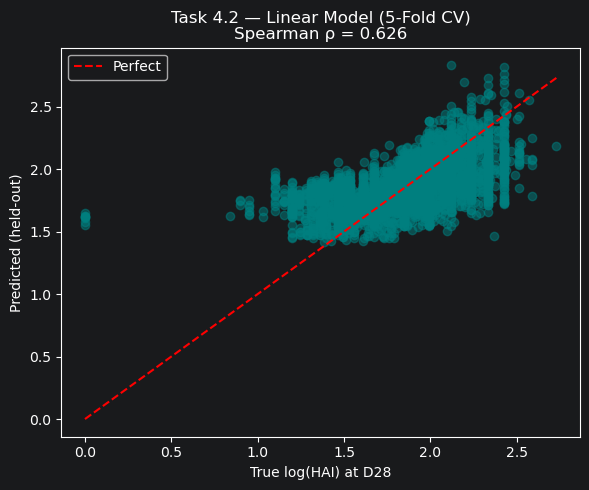

In [12]:
plt.figure(figsize=(6, 5))
plt.scatter(y_vals, y_pred_cv, alpha=0.5, color='teal')
plt.plot([y_vals.min(), y_vals.max()], [y_vals.min(), y_vals.max()], 'r--', label='Perfect')
plt.xlabel('True log(HAI) at D28')
plt.ylabel('Predicted (held-out)')
plt.title(f'Task 4.2 — Linear Model (5-Fold CV)\nSpearman ρ = {rho_cv:.3f}')
plt.legend()
plt.tight_layout()
plt.show()

### Predict on Challenge Set (Task 4.2)
Now we load the unseen challenge data, align its features with our training set, train our model on all available training data, and generate final predictions.

In [13]:
# Load challenge data
challenge_participants = pd.read_csv(DATA_PATH + '/challenge_participants_cleaned.csv')
challenge_hai = pd.read_csv(DATA_PATH + '/challenge_hai_cleaned.csv')
challenge_data = challenge_hai.merge(challenge_participants, on='participant_id', how='inner')

# Extract only the features that exist in the challenge data
existing_cols = [c for c in ['participant_id'] + feature_cols if c in challenge_data.columns]
X_challenge = challenge_data[existing_cols].copy()
challenge_ids = X_challenge.pop('participant_id')

# One-hot encode using the same categorical columns (if they exist in challenge data)
challenge_cat_cols = [c for c in cat_cols if c in X_challenge.columns]
if challenge_cat_cols:
    X_challenge = pd.get_dummies(X_challenge, columns=challenge_cat_cols, drop_first=True)

# Align columns exactly with the training set X
# - Drops columns found in challenge but not in training
# - Adds columns found in training but not in challenge as NaN
# The SimpleImputer in our pipeline will safely fill these NaNs with the training median!
X_challenge = X_challenge.reindex(columns=X.columns)

# Fit the model on 100% of the training data
model.fit(X, y_vals)

# Generate predictions
preds_4_2 = model.predict(X_challenge)

# Save to DataFrame (reverse log1p transform)
challenge_results_4_2 = pd.DataFrame({
    'Participant_ID': challenge_ids,
    'Task_4.2': np.expm1(preds_4_2)
})

os.makedirs('submission', exist_ok=True)
print(f"Generated {len(challenge_results_4_2)} predictions for Task 4.2 Challenge Set.")
challenge_results_4_2.to_csv('submission/task_4_2.csv', index=False)
peek(challenge_results_4_2)

Generated 40 predictions for Task 4.2 Challenge Set.


,Participant_ID,Task_4.2
0,2024_UGA.ID_077,5.887889
1,2024_UGA.ID_086,4.259032
2,2024_UGA.ID_128,8.860877
3,2024_UGA.ID_170,6.272297
4,2024_UGA.ID_179,5.076430
